In [2]:
import pandas as pd

esp_results = pd.read_csv("results_esp.csv")

In [3]:
esp_results["model"] = "ESP"

In [1]:
import pandas as pd

np_esm2_results = pd.read_csv("results_np_classifier.csv")
np_esm2_results["model"] = "NP-ESM2"
np_esm2_results = np_esm2_results.rename(columns={"f1_macro": "f1_score"})

In [2]:
import pandas as pd

np_esm2_gat_results = pd.read_csv("results_gat_np_classifier.csv")
np_esm2_gat_results["model"] = "NP-ESM2-GAT"
np_esm2_gat_results = np_esm2_gat_results.rename(columns={"f1_macro": "f1_score"})

In [3]:
import pandas as pd

np_esm2_focal_bce_results = pd.read_csv("results_np_classifier_focal_bce.csv")
np_esm2_focal_bce_results["model"] = "NP-ESM2-FocalBCE"
np_esm2_focal_bce_results = np_esm2_focal_bce_results.rename(columns={"f1_macro": "f1_score"})

In [4]:
import pandas as pd

np_esm2_weighted_bce_results = pd.read_csv("results_np_classifier_weighted_bce.csv")
np_esm2_weighted_bce_results["model"] = "NP-ESM2-WeightedBCE"
np_esm2_weighted_bce_results = np_esm2_weighted_bce_results.rename(columns={"f1_macro": "f1_score"})

In [5]:
results = pd.concat(
    [
        # esp_results,
        np_esm2_results,
        np_esm2_gat_results,
        np_esm2_focal_bce_results,
        np_esm2_weighted_bce_results
        
    ]
)


In [6]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey HSD test
tukey_results = pairwise_tukeyhsd(
    endog=results['f1_score'],  # Dependent variable
    groups=results['model'],   # Grouping variable
    alpha=0.05                 # Significance level
)

# Print the results
print(tukey_results)

           Multiple Comparison of Means - Tukey HSD, FWER=0.05            
     group1             group2       meandiff p-adj   lower  upper  reject
--------------------------------------------------------------------------
         NP-ESM2    NP-ESM2-FocalBCE  -0.0065 0.9903 -0.0682 0.0552  False
         NP-ESM2         NP-ESM2-GAT   0.0209 0.7695 -0.0408 0.0825  False
         NP-ESM2 NP-ESM2-WeightedBCE   0.0086 0.9774  -0.053 0.0703  False
NP-ESM2-FocalBCE         NP-ESM2-GAT   0.0273 0.5955 -0.0344  0.089  False
NP-ESM2-FocalBCE NP-ESM2-WeightedBCE   0.0151 0.8952 -0.0466 0.0768  False
     NP-ESM2-GAT NP-ESM2-WeightedBCE  -0.0122 0.9407 -0.0739 0.0495  False
--------------------------------------------------------------------------


In [7]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey HSD test
tukey_results = pairwise_tukeyhsd(
    endog=results['mcc'],  # Dependent variable
    groups=results['model'],   # Grouping variable
    alpha=0.05                 # Significance level
)

# Print the results
print(tukey_results)

           Multiple Comparison of Means - Tukey HSD, FWER=0.05            
     group1             group2       meandiff p-adj   lower  upper  reject
--------------------------------------------------------------------------
         NP-ESM2    NP-ESM2-FocalBCE  -0.0275 0.9256 -0.1555 0.1004  False
         NP-ESM2         NP-ESM2-GAT   0.0205  0.967 -0.1074 0.1484  False
         NP-ESM2 NP-ESM2-WeightedBCE  -0.0067 0.9987 -0.1346 0.1212  False
NP-ESM2-FocalBCE         NP-ESM2-GAT    0.048 0.7098 -0.0799 0.1759  False
NP-ESM2-FocalBCE NP-ESM2-WeightedBCE   0.0208 0.9655 -0.1071 0.1487  False
     NP-ESM2-GAT NP-ESM2-WeightedBCE  -0.0272  0.928 -0.1551 0.1007  False
--------------------------------------------------------------------------


In [8]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey HSD test
tukey_results = pairwise_tukeyhsd(
    endog=results['recall'],  # Dependent variable
    groups=results['model'],   # Grouping variable
    alpha=0.05                 # Significance level
)

# Print the results
print(tukey_results)

           Multiple Comparison of Means - Tukey HSD, FWER=0.05            
     group1             group2       meandiff p-adj   lower  upper  reject
--------------------------------------------------------------------------
         NP-ESM2    NP-ESM2-FocalBCE   0.0109 0.9944 -0.1145 0.1363  False
         NP-ESM2         NP-ESM2-GAT   0.0068 0.9986 -0.1186 0.1322  False
         NP-ESM2 NP-ESM2-WeightedBCE   0.0443 0.7455 -0.0811 0.1697  False
NP-ESM2-FocalBCE         NP-ESM2-GAT  -0.0041 0.9997 -0.1295 0.1213  False
NP-ESM2-FocalBCE NP-ESM2-WeightedBCE   0.0334 0.8699  -0.092 0.1588  False
     NP-ESM2-GAT NP-ESM2-WeightedBCE   0.0375 0.8268 -0.0879 0.1629  False
--------------------------------------------------------------------------


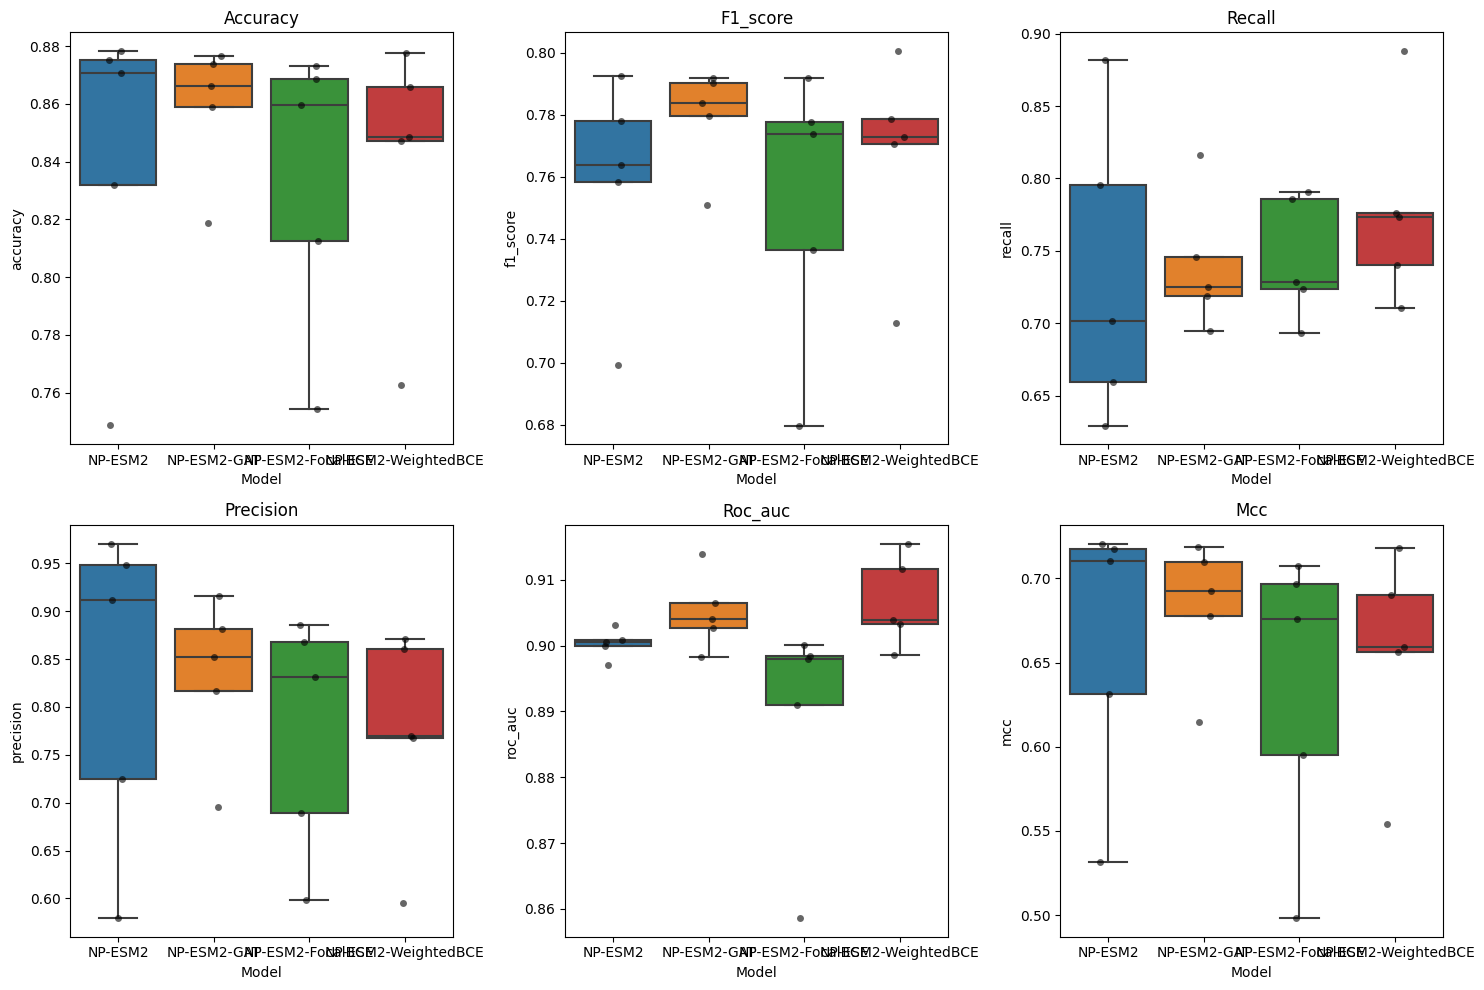

In [9]:
import seaborn as sns

import matplotlib.pyplot as plt

# Define the metrics to plot
metrics = ['accuracy', 'f1_score', 'recall', 'precision', 'roc_auc', 'mcc']

# Create boxplots for each metric with datapoints
plt.figure(figsize=(15, 10))
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=results, x='model', y=metric, showfliers=False)
    sns.stripplot(data=results, x='model', y=metric, color='black', alpha=0.6, jitter=True)
    plt.title(f'{metric.capitalize()}')
    plt.xlabel('Model')
    plt.ylabel(metric)

plt.tight_layout()
plt.show()

In [1]:
import pandas as pd

np_esm2_results = pd.read_csv("results_np_classifier.csv")
np_esm2_results["model"] = "NP-ESM2"
np_esm2_results = np_esm2_results.rename(columns={"f1_macro": "f1_score"})

import pandas as pd

np_esm2_gat_results = pd.read_csv("results_gat_np_classifier.csv")
np_esm2_gat_results["model"] = "NP-ESM2-GAT"
np_esm2_gat_results = np_esm2_gat_results.rename(columns={"f1_macro": "f1_score"})

import pandas as pd

np_esm2_focal_bce_results = pd.read_csv("results_np_classifier_focal_bce.csv")
np_esm2_focal_bce_results["model"] = "NP-ESM2-FocalBCE"
np_esm2_focal_bce_results = np_esm2_focal_bce_results.rename(columns={"f1_macro": "f1_score"})

np_esm2_bce_results = pd.read_csv("results_np_classifier_bce.csv")
np_esm2_bce_results["model"] = "NP-ESM2-BCE"
np_esm2_bce_results = np_esm2_bce_results.rename(columns={"f1_macro": "f1_score"})


In [2]:
results = pd.concat(
    [
        np_esm2_results,
        np_esm2_gat_results,
        np_esm2_focal_bce_results,
        np_esm2_bce_results
        
    ]
)


In [3]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey HSD test
tukey_results = pairwise_tukeyhsd(
    endog=results['f1_score'],  # Dependent variable
    groups=results['model'],   # Grouping variable
    alpha=0.05                 # Significance level
)

# Print the results
print(tukey_results)

          Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1           group2      meandiff p-adj   lower  upper  reject
-----------------------------------------------------------------------
         NP-ESM2      NP-ESM2-BCE   0.0213 0.7018 -0.0348 0.0775  False
         NP-ESM2 NP-ESM2-FocalBCE  -0.0065 0.9872 -0.0626 0.0497  False
         NP-ESM2      NP-ESM2-GAT   0.0209  0.716 -0.0353  0.077  False
     NP-ESM2-BCE NP-ESM2-FocalBCE  -0.0278 0.5072 -0.0839 0.0283  False
     NP-ESM2-BCE      NP-ESM2-GAT  -0.0005    1.0 -0.0566 0.0557  False
NP-ESM2-FocalBCE      NP-ESM2-GAT   0.0273 0.5215 -0.0288 0.0835  False
-----------------------------------------------------------------------


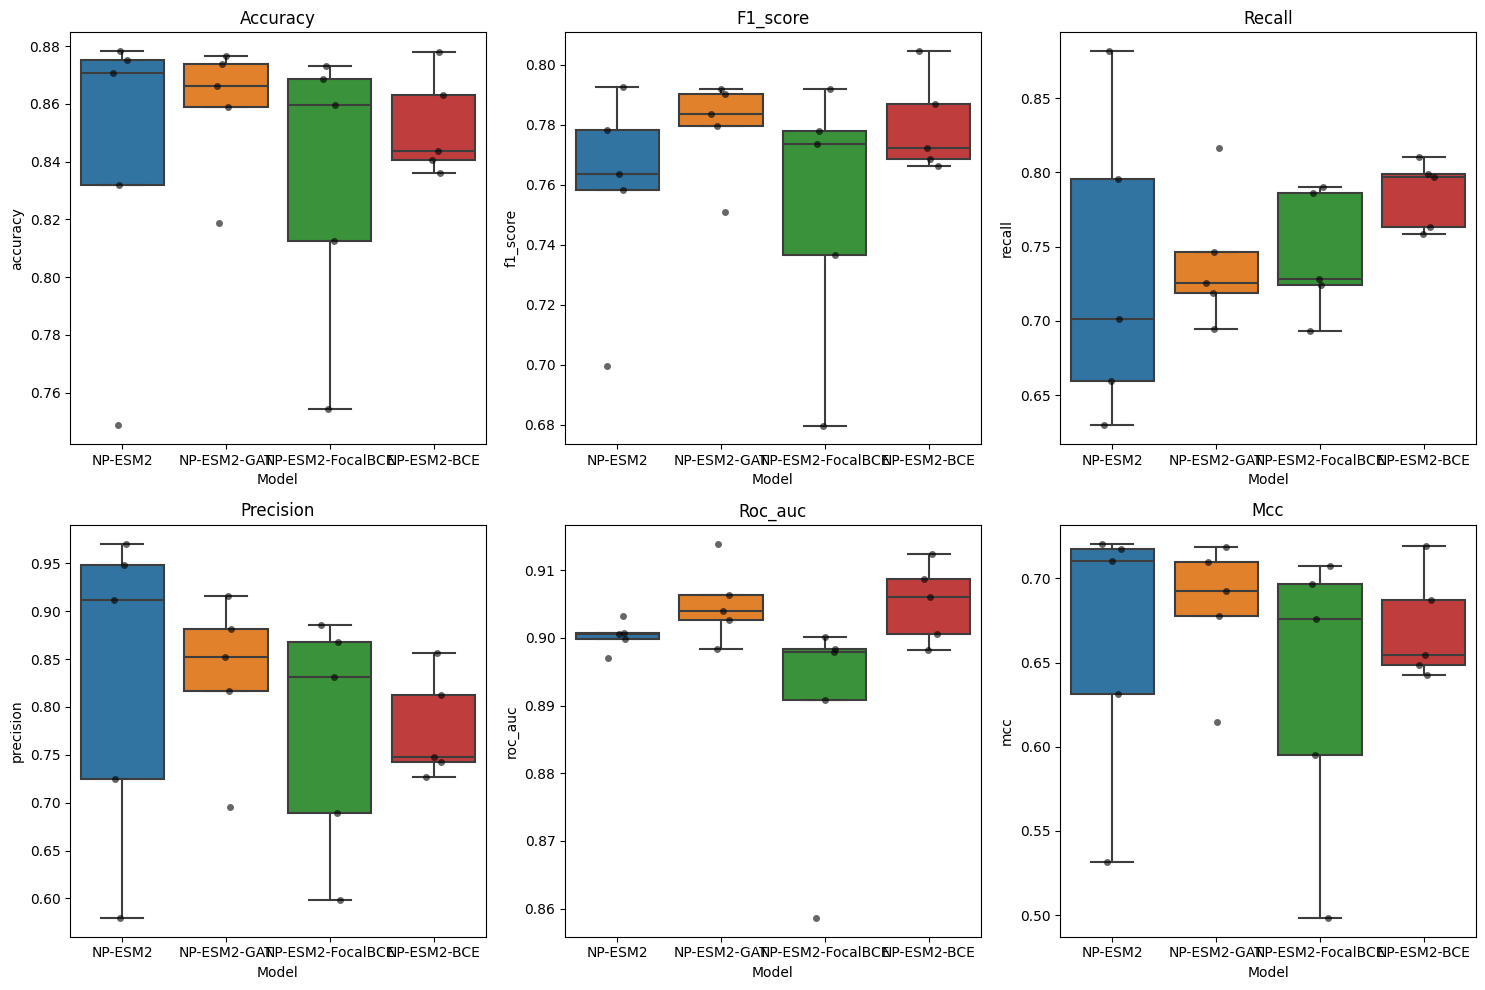

In [4]:
import seaborn as sns

import matplotlib.pyplot as plt

# Define the metrics to plot
metrics = ['accuracy', 'f1_score', 'recall', 'precision', 'roc_auc', 'mcc']

# Create boxplots for each metric with datapoints
plt.figure(figsize=(15, 10))
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=results, x='model', y=metric, showfliers=False)
    sns.stripplot(data=results, x='model', y=metric, color='black', alpha=0.6, jitter=True)
    plt.title(f'{metric.capitalize()}')
    plt.xlabel('Model')
    plt.ylabel(metric)

plt.tight_layout()
plt.show()